In [148]:
# Importing required module

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [149]:
# importing the dataset
df = pd.read_csv('covid_19_Dataset.csv')

df

,DATE,country,NEW Cases,NEW_DEATHS,vaccinated
0,2024-11-01,Argentina,NaN,NaN,unknown
1,2024-11-01,Australia,0.0,0.0,327
2,2024-11-01,Australia,0.0,0.0,327
3,2024-11-01,Brazil,971.0,48.0,430
4,2024-11-01,Canada,176.0,8.0,unknown
...,...,...,...,...,...
160,2024-11-30,Brazil,514.0,25.0,unknown
161,2024-11-30,Canada,1133.0,56.0,438
162,2024-11-30,Canada,1133.0,56.0,438
163,2024-11-30,China,0.0,0.0,unknown


In [150]:
# checking the data information

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   DATE         165 non-null    object 
 1   country      165 non-null    object 
 2    NEW Cases   154 non-null    float64
 3   NEW_DEATHS   139 non-null    float64
 4   vaccinated   165 non-null    object 
dtypes: float64(2), object(3)
memory usage: 6.6+ KB


In [151]:
# checking the data information

df.shape

(165, 5)

In [152]:
# Renaming coumns
df.rename(columns={'NEW Cases': 'new_cases', 'NEW_DEATHS': 'new_deaths', 'DATE': 'date'}, inplace=True)

df


,DATE,country,NEW Cases,new_deaths,vaccinated
0,2024-11-01,Argentina,NaN,NaN,unknown
1,2024-11-01,Australia,0.0,0.0,327
2,2024-11-01,Australia,0.0,0.0,327
3,2024-11-01,Brazil,971.0,48.0,430
4,2024-11-01,Canada,176.0,8.0,unknown
...,...,...,...,...,...
160,2024-11-30,Brazil,514.0,25.0,unknown
161,2024-11-30,Canada,1133.0,56.0,438
162,2024-11-30,Canada,1133.0,56.0,438
163,2024-11-30,China,0.0,0.0,unknown


In [153]:
# Strip leading and trailing spaces from column names
df.columns = df.columns.str.strip().str.lower()

df


,date,country,new cases,new_deaths,vaccinated
0,2024-11-01,Argentina,NaN,NaN,unknown
1,2024-11-01,Australia,0.0,0.0,327
2,2024-11-01,Australia,0.0,0.0,327
3,2024-11-01,Brazil,971.0,48.0,430
4,2024-11-01,Canada,176.0,8.0,unknown
...,...,...,...,...,...
160,2024-11-30,Brazil,514.0,25.0,unknown
161,2024-11-30,Canada,1133.0,56.0,438
162,2024-11-30,Canada,1133.0,56.0,438
163,2024-11-30,China,0.0,0.0,unknown


In [154]:
# Renaming coumns again


df.rename(columns={'new cases': 'new_cases'}, inplace=True)

df

,date,country,new_cases,new_deaths,vaccinated
0,2024-11-01,Argentina,NaN,NaN,unknown
1,2024-11-01,Australia,0.0,0.0,327
2,2024-11-01,Australia,0.0,0.0,327
3,2024-11-01,Brazil,971.0,48.0,430
4,2024-11-01,Canada,176.0,8.0,unknown
...,...,...,...,...,...
160,2024-11-30,Brazil,514.0,25.0,unknown
161,2024-11-30,Canada,1133.0,56.0,438
162,2024-11-30,Canada,1133.0,56.0,438
163,2024-11-30,China,0.0,0.0,unknown


In [155]:
# Converting Date column data type

df['date'] = pd.to_datetime(df['date'], format='mixed', dayfirst=True)

In [156]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        165 non-null    datetime64[ns]
 1   country     165 non-null    object        
 2   new_cases   154 non-null    float64       
 3   new_deaths  139 non-null    float64       
 4   vaccinated  165 non-null    object        
dtypes: datetime64[ns](1), float64(2), object(2)
memory usage: 6.6+ KB


In [157]:
# viewing data

df

,date,country,new_cases,new_deaths,vaccinated
0,2024-11-01,Argentina,NaN,NaN,unknown
1,2024-11-01,Australia,0.0,0.0,327
2,2024-11-01,Australia,0.0,0.0,327
3,2024-11-01,Brazil,971.0,48.0,430
4,2024-11-01,Canada,176.0,8.0,unknown
...,...,...,...,...,...
160,2024-11-30,Brazil,514.0,25.0,unknown
161,2024-11-30,Canada,1133.0,56.0,438
162,2024-11-30,Canada,1133.0,56.0,438
163,2024-11-30,China,0.0,0.0,unknown


In [158]:
# Checking columns with null values

df.isnull().sum()

date           0
country        0
new_cases     11
new_deaths    26
vaccinated     0
dtype: int64

In [159]:
# viewing rows with null values

df[df.isnull().any(axis=1)]

,date,country,new_cases,new_deaths,vaccinated
0,2024-11-01,Argentina,NaN,NaN,unknown
7,2024-11-02,Australia,0.0,NaN,336
12,2024-11-03,Australia,NaN,NaN,474
13,2024-11-03,Brazil,641.0,NaN,47
22,2024-11-05,Argentina,283.0,NaN,41
30,2024-11-06,Canada,152.0,NaN,421
40,2024-11-08,Brazil,212.0,NaN,313
55,2024-11-11,Brazil,NaN,NaN,285
59,2024-11-12,Australia,796.0,NaN,433
60,2024-11-12,Brazil,NaN,NaN,182


In [160]:
# Dropping rows with too much unknown or NaN

df.drop(index=[0,7,12,55,60,76,92,102,108,109,133,145,155], inplace=True)

In [161]:
# viewing rows with null values again


df[df.isnull().any(axis=1)]

,date,country,new_cases,new_deaths,vaccinated
13,2024-11-03,Brazil,641.0,NaN,47
22,2024-11-05,Argentina,283.0,NaN,41
30,2024-11-06,Canada,152.0,NaN,421
40,2024-11-08,Brazil,212.0,NaN,313
59,2024-11-12,Australia,796.0,NaN,433
64,2024-11-13,Australia,783.0,NaN,436
85,2024-11-17,Argentina,759.0,NaN,397
86,2024-11-17,Argentina,759.0,NaN,397
93,2024-11-18,Australia,882.0,NaN,458
115,2024-11-22,Argentina,896.0,NaN,349


In [162]:
# Checking for duplicate

df[df.duplicated(keep=False)]

,date,country,new_cases,new_deaths,vaccinated
1,2024-11-01,Australia,0.0,0.0,327
2,2024-11-01,Australia,0.0,0.0,327
18,2024-11-04,Brazil,793.0,39.0,137
19,2024-11-04,Brazil,793.0,39.0,137
38,2024-11-08,Australia,313.0,15.0,486
39,2024-11-08,Australia,313.0,15.0,486
68,2024-11-14,Argentina,806.0,40.0,11
69,2024-11-14,Argentina,806.0,40.0,11
83,2024-11-16,China,727.0,36.0,326
84,2024-11-16,China,727.0,36.0,326


In [163]:
# Dropping duplicate

df.drop_duplicates(inplace=True)

In [164]:
# confirming if duplicates have been removed

df[df.duplicated()]


,date,country,new_cases,new_deaths,vaccinated


In [165]:
# viewing rows with null values again


df[df.isnull().any(axis=1)]

,date,country,new_cases,new_deaths,vaccinated
13,2024-11-03,Brazil,641.0,NaN,47
22,2024-11-05,Argentina,283.0,NaN,41
30,2024-11-06,Canada,152.0,NaN,421
40,2024-11-08,Brazil,212.0,NaN,313
59,2024-11-12,Australia,796.0,NaN,433
64,2024-11-13,Australia,783.0,NaN,436
85,2024-11-17,Argentina,759.0,NaN,397
93,2024-11-18,Australia,882.0,NaN,458
115,2024-11-22,Argentina,896.0,NaN,349
130,2024-11-24,Canada,597.0,NaN,319


In [166]:
df.head(20)

,date,country,new_cases,new_deaths,vaccinated
1,2024-11-01,Australia,0.0,0.0,327
3,2024-11-01,Brazil,971.0,48.0,430
4,2024-11-01,Canada,176.0,8.0,unknown
5,2024-11-01,China,1034.0,51.0,462
6,2024-11-02,Argentina,23.0,1.0,195
8,2024-11-02,Brazil,185.0,9.0,173
9,2024-11-02,Canada,615.0,30.0,369
10,2024-11-02,China,376.0,18.0,61
11,2024-11-03,Argentina,337.0,16.0,425
13,2024-11-03,Brazil,641.0,NaN,47


In [167]:
# checking columns with unknown values

df[df['vaccinated'] == 'unknown']

,date,country,new_cases,new_deaths,vaccinated
4,2024-11-01,Canada,176.0,8.0,unknown
21,2024-11-04,China,696.0,34.0,unknown
37,2024-11-08,Argentina,665.0,33.0,unknown
49,2024-11-10,Australia,405.0,20.0,unknown
73,2024-11-14,China,718.0,35.0,unknown
74,2024-11-15,Argentina,728.0,36.0,unknown
110,2024-11-21,Argentina,1248.0,62.0,unknown
132,2024-11-25,Argentina,1063.0,53.0,unknown
134,2024-11-25,Brazil,357.0,17.0,unknown
158,2024-11-30,Argentina,1619.0,80.0,unknown


In [168]:
# checking columns with unknown values

column_brazil = df[df['country'] == 'Brazil']

column_brazil.head(50)

,date,country,new_cases,new_deaths,vaccinated
3,2024-11-01,Brazil,971.0,48.0,430
8,2024-11-02,Brazil,185.0,9.0,173
13,2024-11-03,Brazil,641.0,NaN,47
18,2024-11-04,Brazil,793.0,39.0,137
24,2024-11-05,Brazil,638.0,31.0,346
29,2024-11-06,Brazil,10.0,0.0,2
34,2024-11-07,Brazil,605.0,30.0,121
40,2024-11-08,Brazil,212.0,NaN,313
45,2024-11-09,Brazil,918.0,45.0,57
50,2024-11-10,Brazil,57.0,2.0,18


In [169]:
# viewing last 50 row to observe how to handle the missing data
df.tail(50)

,date,country,new_cases,new_deaths,vaccinated
103,2024-11-20,Argentina,589.0,29.0,120
105,2024-11-20,Australia,749.0,37.0,421
106,2024-11-20,Brazil,587.0,29.0,11
110,2024-11-21,Argentina,1248.0,62.0,unknown
111,2024-11-21,Australia,626.0,31.0,499
112,2024-11-21,Brazil,896.0,44.0,187
113,2024-11-21,Canada,606.0,30.0,465
114,2024-11-21,China,588.0,29.0,107
115,2024-11-22,Argentina,896.0,NaN,349
116,2024-11-22,Australia,741.0,37.0,346


In [ ]:
# selecting columns with number data types

df_num = df.select_dtypes(include=['number'])


In [171]:
# using iterative imputer to handle missing values

from sklearn.experimental import enable_iterative_imputer as eii

from sklearn.impute import IterativeImputer as ii


iterate = ii()

df_iterate = pd.DataFrame(iterate.fit_transform(df_num), columns=df_num.columns, index=df_num.index)


In [172]:
# Applying the transformed data to a copy of df

df_imputed = df.copy()

df_imputed

df_imputed[df_num.columns] = df_iterate

df_imputed.head(20)

,date,country,new_cases,new_deaths,vaccinated
1,2024-11-01,Australia,0.0,0.000000,327
3,2024-11-01,Brazil,971.0,48.000000,430
4,2024-11-01,Canada,176.0,8.000000,unknown
5,2024-11-01,China,1034.0,51.000000,462
6,2024-11-02,Argentina,23.0,1.000000,195
8,2024-11-02,Brazil,185.0,9.000000,173
9,2024-11-02,Canada,615.0,30.000000,369
10,2024-11-02,China,376.0,18.000000,61
11,2024-11-03,Argentina,337.0,16.000000,425
13,2024-11-03,Brazil,641.0,31.585458,47


In [173]:
# converting the vaccinated columns data type from object to float so that unknown value can be converted to NaN and be treated seperately

df_imputed['vaccinated'] = pd.to_numeric(df_imputed['vaccinated'], errors='coerce')

df_imputed['vaccinated'].astype(float)

df_imputed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 137 entries, 1 to 163
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        137 non-null    datetime64[ns]
 1   country     137 non-null    object        
 2   new_cases   137 non-null    float64       
 3   new_deaths  137 non-null    float64       
 4   vaccinated  125 non-null    float64       
dtypes: datetime64[ns](1), float64(3), object(1)
memory usage: 6.4+ KB


In [174]:
df_imputed

,date,country,new_cases,new_deaths,vaccinated
1,2024-11-01,Australia,0.0,0.0,327.0
3,2024-11-01,Brazil,971.0,48.0,430.0
4,2024-11-01,Canada,176.0,8.0,NaN
5,2024-11-01,China,1034.0,51.0,462.0
6,2024-11-02,Argentina,23.0,1.0,195.0
...,...,...,...,...,...
158,2024-11-30,Argentina,1619.0,80.0,NaN
159,2024-11-30,Australia,1473.0,73.0,428.0
160,2024-11-30,Brazil,514.0,25.0,NaN
161,2024-11-30,Canada,1133.0,56.0,438.0


In [175]:
# Checking the aggregate of the data

df_imputed.describe()

,date,new_cases,new_deaths,vaccinated
count,137,137.000000,137.000000,125.00000
mean,2024-11-13 07:52:59.562043904,594.182482,29.250383,308.78400
min,2024-05-11 00:00:00,0.000000,0.000000,2.00000
25%,2024-11-08 00:00:00,294.000000,14.000000,174.00000
50%,2024-11-15 00:00:00,597.000000,29.390910,352.00000
75%,2024-11-23 00:00:00,806.000000,40.000000,433.00000
max,2024-11-30 00:00:00,1730.000000,86.000000,499.00000
std,NaN,407.232919,20.313064,150.47262


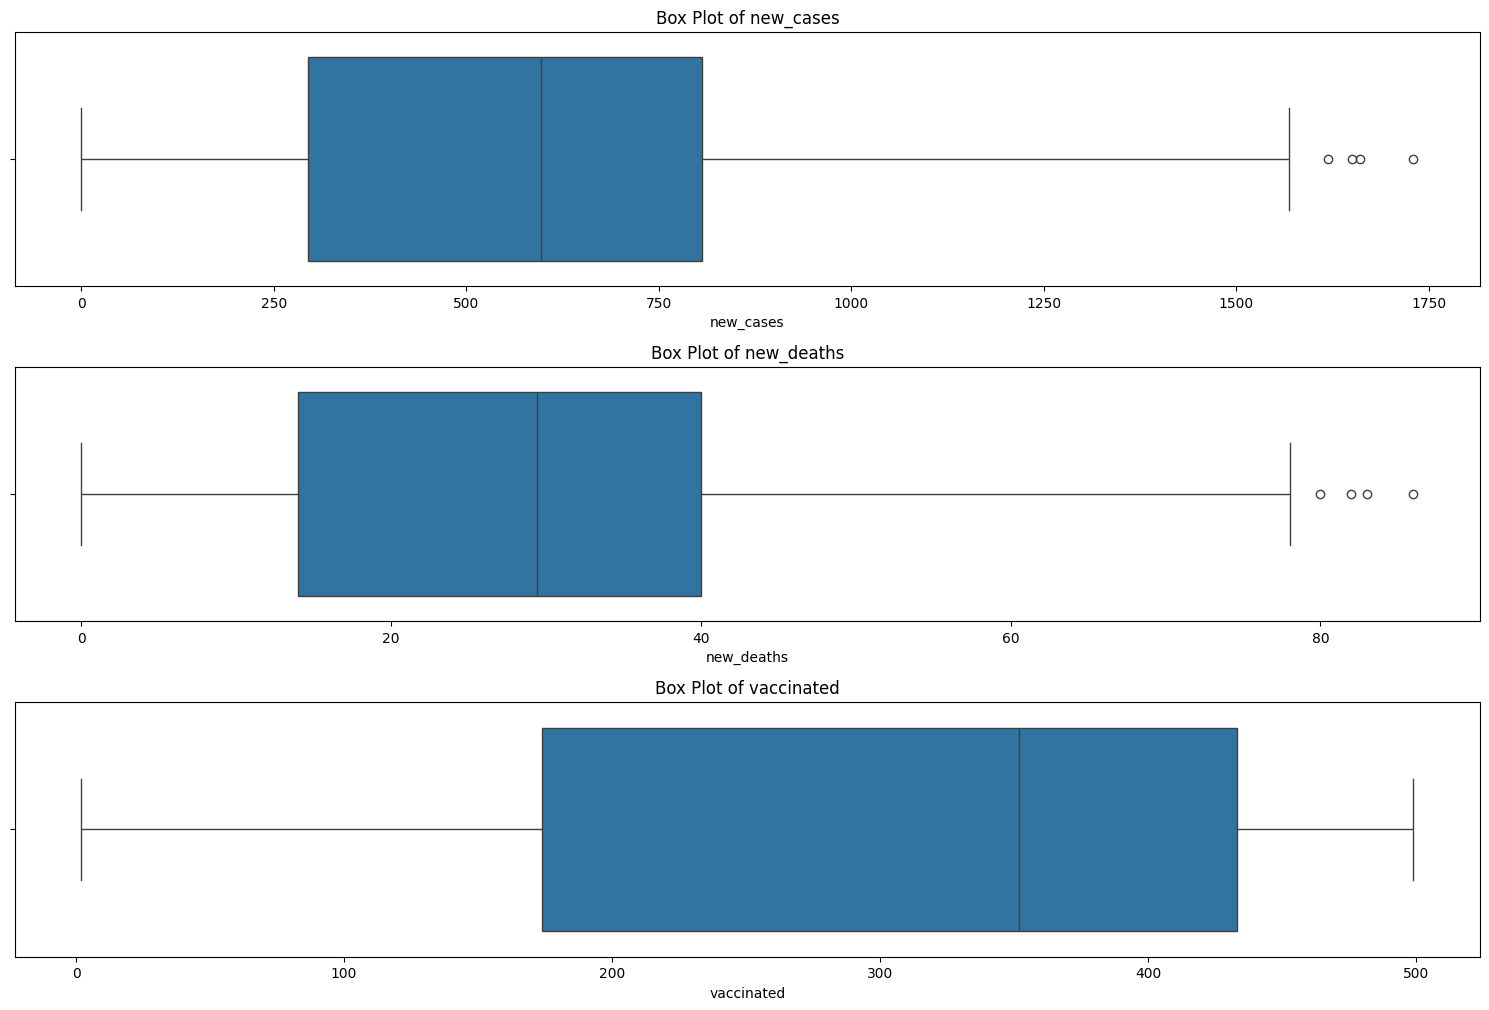

In [176]:
# filtering numerical columns for box plot to check for outliers

numerical_columns = df_imputed.select_dtypes(include=['number'])

# plotting box plot for each numerical columns

plt.figure(figsize=( 15, 50))

for i, col in enumerate(numerical_columns, 1):
    plt.subplot(15, 1,i)
    sns.boxplot(x=df_imputed[col])
    plt.title(f'Box Plot of {col}')
    plt.tight_layout()

plt.show()



#  

In [177]:
# From the box plot it shows that we don't have much outliers so we can perform analysis

In [178]:
df_imputed.groupby('country')

In [179]:
# viewing last 50 row to observe how to handle the missing data
df.tail(50)

,date,country,new_cases,new_deaths,vaccinated
103,2024-11-20,Argentina,589.0,29.0,120
105,2024-11-20,Australia,749.0,37.0,421
106,2024-11-20,Brazil,587.0,29.0,11
110,2024-11-21,Argentina,1248.0,62.0,unknown
111,2024-11-21,Australia,626.0,31.0,499
112,2024-11-21,Brazil,896.0,44.0,187
113,2024-11-21,Canada,606.0,30.0,465
114,2024-11-21,China,588.0,29.0,107
115,2024-11-22,Argentina,896.0,NaN,349
116,2024-11-22,Australia,741.0,37.0,346


In [180]:
# Calculate cumulative sums
df['cumulative_cases'] = df.groupby('country')['new_cases'].cumsum()
df['cumulative_deaths'] = df.groupby('country')['new_deaths'].cumsum()

In [ ]:
# Analyzing daily trends in infection and fatalities

sort_df = df_imputed.sort_values(['country', 'new_cases']).reset_index(drop=True)

daily_trend = sort_df[['country', 'date', 'new_cases', 'new_deaths']]


daily_trend.head(10)

,country,date,new_cases,new_deaths
0,Argentina,2024-11-02,23.0,1.000000
1,Argentina,2024-11-04,96.0,4.000000
2,Argentina,2024-11-12,217.0,10.000000
3,Argentina,2024-11-05,283.0,13.729814
4,Argentina,2024-11-03,337.0,16.000000
5,Argentina,2024-11-09,376.0,18.000000
6,Argentina,2024-11-06,377.0,18.000000
7,Argentina,2024-11-07,391.0,19.000000
8,Argentina,2024-11-10,454.0,22.000000
9,Argentina,2024-11-11,532.0,26.000000


In [191]:
# Calculate cumulative cases and deaths per country

sort_df['cumulative_cases']= sort_df.groupby('country')['new_cases'].cumsum()
sort_df['cumulative_deaths'] = sort_df.groupby('country')['new_deaths'].cumsum()

cumulative_data = (sort_df[['country', 'date', 'new_cases', 'new_deaths', 'cumulative_cases', 'cumulative_deaths']])

cumulative_data.head(20)

,country,date,new_cases,new_deaths,cumulative_cases,cumulative_deaths
0,Argentina,2024-11-02,23.0,1.000000,23.0,1.000000
1,Argentina,2024-11-04,96.0,4.000000,119.0,5.000000
2,Argentina,2024-11-12,217.0,10.000000,336.0,15.000000
3,Argentina,2024-11-05,283.0,13.729814,619.0,28.729814
4,Argentina,2024-11-03,337.0,16.000000,956.0,44.729814
5,Argentina,2024-11-09,376.0,18.000000,1332.0,62.729814
6,Argentina,2024-11-06,377.0,18.000000,1709.0,80.729814
7,Argentina,2024-11-07,391.0,19.000000,2100.0,99.729814
8,Argentina,2024-11-10,454.0,22.000000,2554.0,121.729814
9,Argentina,2024-11-11,532.0,26.000000,3086.0,147.729814


In [184]:
# Checking aggregate of the country 

df_imputed['country'].agg(['nunique', 'unique'])

nunique                                                5
unique     [Australia, Brazil, Canada, China, Argentina]
Name: country, dtype: object

In [185]:
# mapping country to region

country_to_region = {
    'Australia' : 'Oceanic', 'Brazil':'South_America', 'Canada': 'North_America', 'China': 'Asia', 'Argentina' : 'South_America'
}

df_imputed['region'] = df['country'].map(country_to_region)

df_imputed

,date,country,new_cases,new_deaths,vaccinated,region
1,2024-11-01,Australia,0.0,0.0,327.0,Oceanic
3,2024-11-01,Brazil,971.0,48.0,430.0,South_America
4,2024-11-01,Canada,176.0,8.0,NaN,North_America
5,2024-11-01,China,1034.0,51.0,462.0,Asia
6,2024-11-02,Argentina,23.0,1.0,195.0,South_America
...,...,...,...,...,...,...
158,2024-11-30,Argentina,1619.0,80.0,NaN,South_America
159,2024-11-30,Australia,1473.0,73.0,428.0,Oceanic
160,2024-11-30,Brazil,514.0,25.0,NaN,South_America
161,2024-11-30,Canada,1133.0,56.0,438.0,North_America


In [ ]:
# Death rate across different countries and region

summary = df_imputed.groupby(['country', 'region'])[['new_cases', 'new_deaths']].sum().reset_index()

summary['death_rate (%)'] = (summary['new_deaths'] / summary['new_cases']) * 100


print('Summary of Death Rate across different countries and region')
print('- - - - - - - - - - - * * * * * * - - - - - - - - - - - ')
print(summary)

Summary of Death Rate across different countries and region
- - - - - - - - - - - * * * * * * - - - - - - - - - - - 
     country         region  new_cases   new_deaths  death_rate (%)
0  Argentina  South_America    21422.0  1056.504516        4.931867
1  Australia        Oceanic    20941.0  1036.771528        4.950917
2     Brazil  South_America    11543.0   562.774069        4.875458
3     Canada  North_America    13877.0   681.252341        4.909219
4      China           Asia    13620.0   670.000000        4.919236


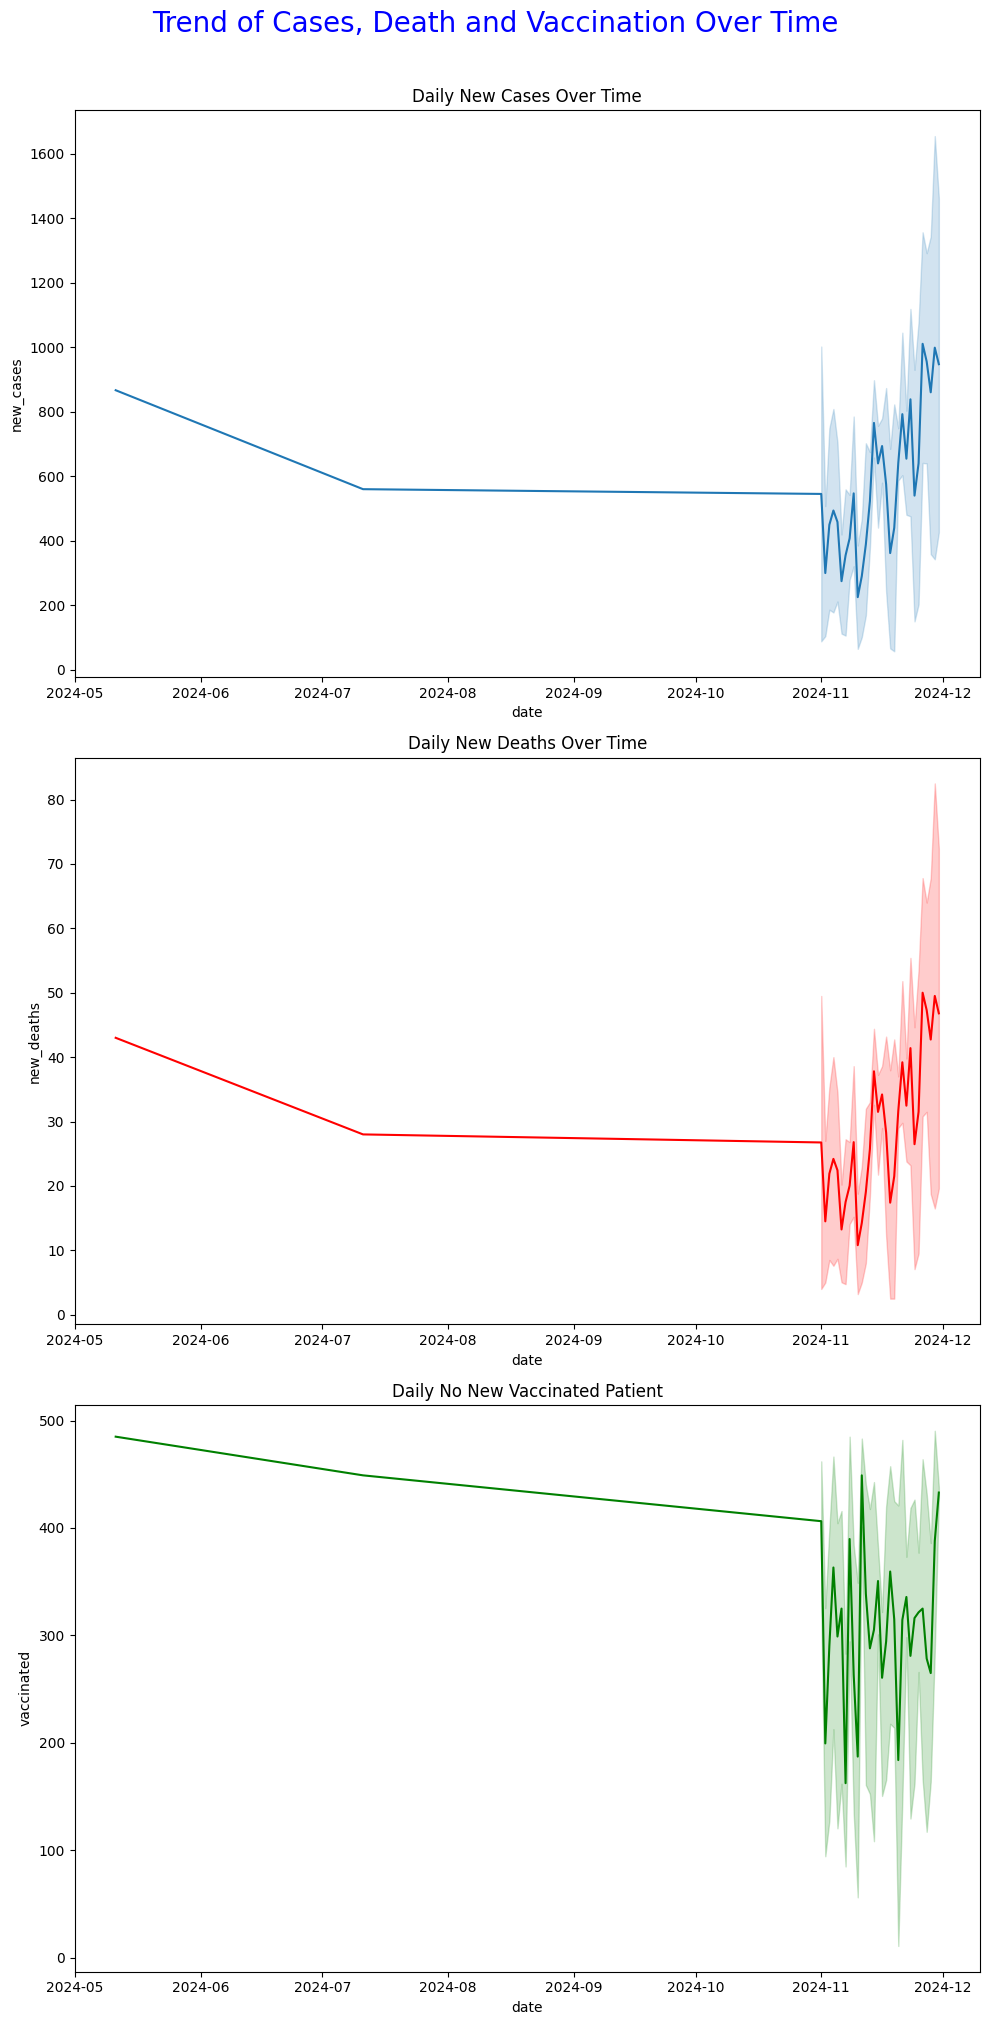

In [187]:
# showing trend of cases, deaths and vaccination over time

fig, axs = plt.subplots(3,1, figsize=(10, 20))

axs = axs.flatten()

sns.lineplot(data= df_imputed,  x ='date', y = 'new_cases', ax=axs[0]) 
axs[0].set_title('Daily New Cases Over Time')

sns.lineplot(data =  df_imputed, x = 'date', y = 'new_deaths', color='red', ax= axs[1])
axs[1].set_title('Daily New Deaths Over Time')

sns.lineplot(data=df_imputed, x = 'date', y = 'vaccinated',color='green', ax= axs[2])
axs[2].set_title('Daily No New Vaccinated Patient')

plt.suptitle('Trend of Cases, Death and Vaccination Over Time', fontsize=20, color='blue', y = 1.01)

plt.tight_layout()
plt.show()

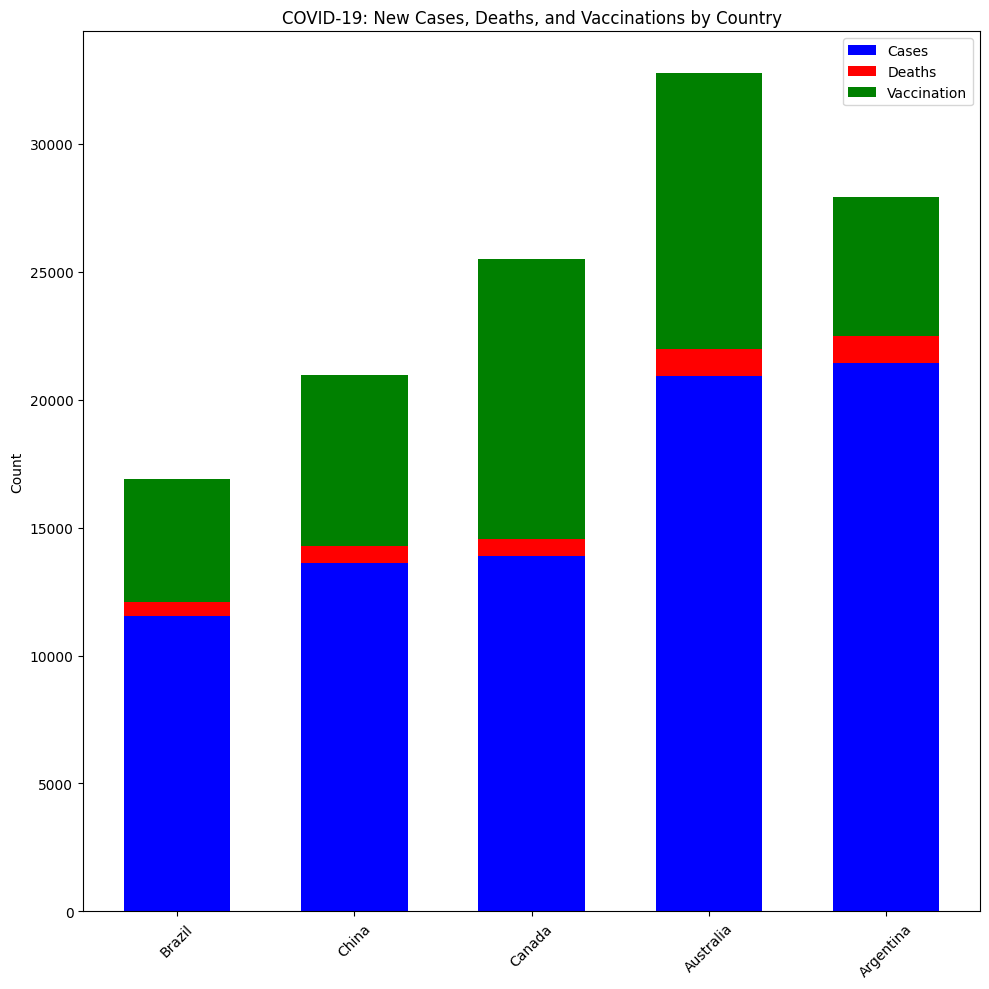

In [ ]:
# Comparing cases, deaths and vaccinations by country

grouping_data = (df_imputed.groupby(['country'])[['new_cases', 'new_deaths', 'vaccinated']].sum().reset_index()).sort_values(['new_cases'])

x = np.arange(len(grouping_data))
width = 0.6

fig, ax = plt.subplots(figsize=(10, 10))

ax.bar(x, grouping_data['new_cases'], width, label= 'Cases', color='blue')
ax.bar(x, grouping_data['new_deaths'],width, label='Deaths', bottom=grouping_data['new_cases'], color='red')
ax.bar(x, grouping_data['vaccinated'],width,  label='Vaccination', bottom= grouping_data['new_cases'] +   grouping_data['new_deaths'], color='green')


ax.set_xticks(x)
ax.set_xticklabels(grouping_data['country'], rotation=45)
ax.set_ylabel("Count")
ax.set_title("COVID-19: New Cases, Deaths, and Vaccinations by Country")
plt.tight_layout()
ax.legend()

plt.show()

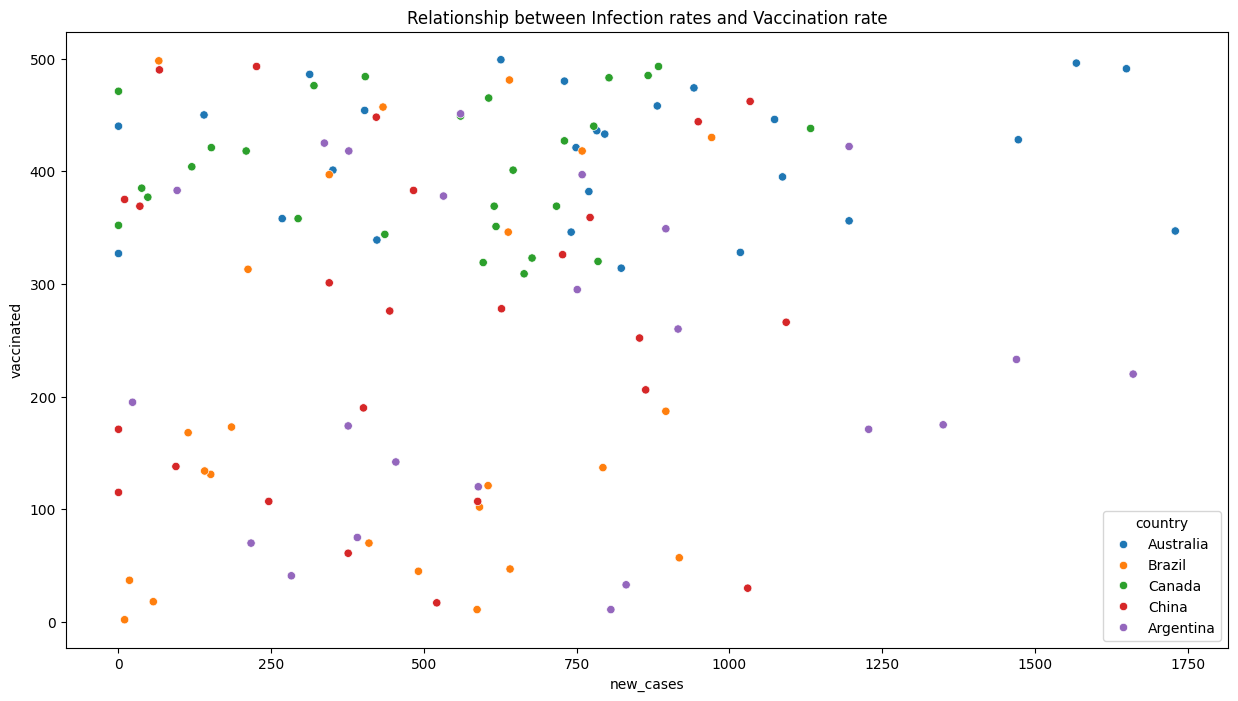

In [192]:
# Relationship betwwen infection rates and vaccination rates

plt.figure(figsize=(15,8))

sns.scatterplot(data=df_imputed, x='new_cases', y = 'vaccinated', hue='country')

plt.title('Relationship between Infection rates and Vaccination rate')
plt.show()
